In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [4]:
df = pd.read_csv('/content/featured_titanic.csv')

In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,IsAlone,Title,AgeGroup,FareGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2,0,Mr,Young Adult,Low
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2,0,Mrs,Adult,Premium
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1,1,Miss,Young Adult,Medium
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2,0,Mrs,Young Adult,Premium
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1,1,Mr,Young Adult,Medium


Select Features - We don't need every column.

In [14]:
features = ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize', 'IsAlone']

X = df[features]
y = df['Survived']

Handle Categorical Columns

In [15]:
le = LabelEncoder()
X['Sex'] = le.fit_transform(X['Sex'])
X['Embarked'] = le.fit_transform(X['Embarked'])

/tmp/ipykernel_2848/2263262632.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Sex'] = le.fit_transform(X['Sex'])
/tmp/ipykernel_2848/2263262632.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Embarked'] = le.fit_transform(X['Embarked'])


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
X_train
X_test
y_train
y_test

,Survived
709,1
439,0
840,0
720,1
39,1
...,...
433,0
773,0
25,1
84,1


In [23]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(712, 7)
(179, 7)
(712,)
(179,)


Train Logistic Regression

In [25]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

Make Predictions

In [26]:
y_pred_lr = lr.predict(X_test)

Decision Tree

In [27]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

Random Forest

In [28]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

Compare Predictions

In [30]:
print(y_pred_lr[:10])
print(y_pred_dt[:10])
print(y_pred_rf[:10])


[0 0 0 1 1 1 1 0 1 1]
[0 0 0 1 1 0 1 0 1 1]
[0 0 0 1 0 1 1 0 1 1]


Compare with Actual Values

In [32]:
print(y_test.values[:10])

[1 0 0 1 1 1 1 0 1 1]


Calculate Accuracy

In [33]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print('Logistic Regression Accuracy:', accuracy_lr)

Logistic Regression Accuracy: 0.7988826815642458


In [34]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print('Decision Tree Accuracy:', accuracy_dt)

Decision Tree Accuracy: 0.776536312849162


In [35]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print('Random Forest:', accuracy_rf)

Random Forest: 0.8324022346368715


Confusion Matrix

In [36]:
cm = confusion_matrix(y_test, y_pred_rf)
print(cm)

[[91 14]
 [16 58]]


Classification Report

In [37]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.85      0.87      0.86       105
           1       0.81      0.78      0.79        74

    accuracy                           0.83       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.83      0.83      0.83       179



Feature Importance

In [41]:
importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance.sort_values(
    by='Importance',
    ascending=False
)

,Feature,Importance
3,Fare,0.278753
1,Sex,0.268352
2,Age,0.261373
0,Pclass,0.079434
5,FamilySize,0.066114
4,Embarked,0.031923
6,IsAlone,0.014051


Plot Feature Importance

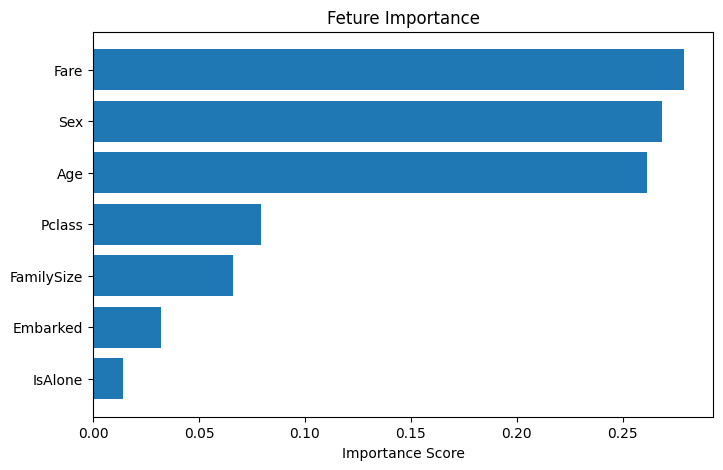

In [43]:
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=True
)

plt.figure(figsize=(8,5))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.title('Feture Importance')
plt.xlabel('Importance Score')

plt.show()

Compare All Models

In [44]:
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_lr,
        accuracy_dt,
        accuracy_rf
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.798883
1,Decision Tree,0.776536
2,Random Forest,0.832402
